# Natural Language Processing (NLP) using Bert

On this code, We'll will do sentiment analysis with BERT in english

##1) Importing Frameworks and Libraries

In [1]:
import torch
from torch import nn
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from datasets import load_dataset
from transformers import BertModel, BertTokenizer, get_scheduler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
import time

##2) Defining the device (GPU/CPU)

In [ ]:
# check if we have cuda installed
if torch.cuda.is_available():    # to use GPU
    device = torch.device("cuda")
    print(f"There are {torch.cuda.device_count()} GPU(s) available.")
    print("GPU is: ", torch.cuda.get_device_name(0))
else:
    print("No GPU available, using the CPU instead.")
    device = torch.device("cpu")

There are 1 GPU(s) available.
GPU is: Tesla T4


##3) Model Fine-tuning

We'll fine-tune BERT with IMDB dataset, that has movies criticts.

###3.1) Main Configurations

In [ ]:
MAX_LEN = 128       # Maximum length of texts
BATCH_SIZE = 8      # Batch size
EPOCHS = 3         # Number of epochs
LR = 5e-5           # Learning rate

###3.2) Training

In [ ]:
# Dataset Class
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        # Tokenizing the text
        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label": torch.tensor(label, dtype=torch.long)
        }

# Custom Model based on BERT
class CustomBERTModel(nn.Module):
    def __init__(self, num_labels):
        super(CustomBERTModel, self).__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_labels)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.pooler_output
        return self.classifier(cls_output)

# Training Function
def train_model(model, data_loader, optimizer, criterion, lr_scheduler):
    model.train()
    total_loss = 0

    for batch in data_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        lr_scheduler.step()

        total_loss += loss.item()

    return total_loss / len(data_loader)

# Evaluation Function
def evaluate_model(model, data_loader):
    model.eval()
    predictions = []
    true_labels = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs, dim=1)
            predictions.extend(preds.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(true_labels, predictions)
    return accuracy

# Load IMDB dataset
imdb = load_dataset("imdb")

data = {
    "texts": imdb["train"]["text"],
    "labels": imdb["train"]["label"]
}

df = pd.DataFrame(data)

# Splitting data into train and validation
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df["texts"].values,
    df["labels"].values,
    test_size=0.2,
    random_state=42
)

# Loading BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Creating datasets and data loaders
train_dataset = TextDataset(train_texts, train_labels, tokenizer, MAX_LEN)
val_dataset = TextDataset(val_texts, val_labels, tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

# Creating the model
# Changed num_labels to 2 because IMDB is binary (Positive/Negative)
model = CustomBERTModel(num_labels=2)
model = model.to(device)

# Configuring optimizer and loss function
optimizer = AdamW(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

# Configuring learning rate scheduler
num_training_steps = len(train_loader) * EPOCHS
lr_scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps
)

# Training Loop
for epoch in range(EPOCHS):
    start_time = time.time()
    train_loss = train_model(model, train_loader, optimizer, criterion, lr_scheduler)
    val_accuracy = evaluate_model(model, val_loader)
    end_time = time.time()

    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print(f"Training: Loss = {train_loss:.4f}")
    print(f"Validation: Accuracy = {val_accuracy:.4f}")
    print(f"Time: {end_time - start_time:.2f} seconds\n")

# Save model and tokenizer
torch.save(model.state_dict(), "bert_model.pth")
tokenizer.save_pretrained("bert_tokenizer")

# Testing with new data
test_texts = ["The weather forecast is for tomorrow.", "BERT is a powerful model."]
test_dataset = TextDataset(test_texts, [0, 0], tokenizer, MAX_LEN) # Dummy labels
test_loader = DataLoader(test_dataset, batch_size=1)

# Predicting classes
model.eval()
predictions = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs, dim=1)
        predictions.extend(preds.cpu().numpy())

print(f"Predictions: {predictions}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Epoch 1/3
Training: Loss = 0.3908
Validation: Accuracy = 0.8440
Time: 626.95 seconds

Epoch 2/3
Training: Loss = 0.1956
Validation: Accuracy = 0.8796
Time: 622.70 seconds

Epoch 3/3
Training: Loss = 0.0539
Validation: Accuracy = 0.8780
Time: 621.42 seconds

Predictions: [np.int64(1), np.int64(1)]


##4) Sentiment analysis

In [ ]:
# --- 1. Initial Configurations ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MAX_LEN = 128
MODEL_PATH = "bert_model.pth"
TOKENIZER_PATH = "bert_tokenizer"

# Label Mapping
label_map = {
    0: "🔴 Negative",
    1: "🟢 Positive"
}

# --- 2. Redefining Model Architecture ---
class CustomBERTModel(nn.Module):
    def __init__(self, num_labels):
        super(CustomBERTModel, self).__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_labels)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.pooler_output
        return self.classifier(cls_output)

# --- 3. Loading Function ---
def load_trained_model():
    print("Loading tokenizer and model...")
    tokenizer = BertTokenizer.from_pretrained(TOKENIZER_PATH)
    # Changed num_labels from 3 to 2 to match the trained model's output classes.
    model = CustomBERTModel(num_labels=2)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.to(device)
    model.eval()
    return model, tokenizer

# --- 4. Prediction Function ---
def predict_sentiment(text, model, tokenizer):
    encoding = tokenizer(
        text,
        max_length=MAX_LEN,
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    )

    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        confidence, predicted_class = torch.max(probs, dim=1)

    return predicted_class.item(), confidence.item()

# --- 5. Test Execution ---
if __name__ == "__main__":
    model, tokenizer = load_trained_model()

    # Data Structure: List of tuples (Review Text, Correct Label ID)
    # 0 = Negative, 1 = Neutral, 2 = Positive
    test_data = [
        # --- NEGATIVES (True Label = 0) ---
        ("The product arrived broken and the box was torn. Terrible!", 0),
        ("I do not recommend it, it stopped working in two days.", 0),
        ("Worst customer service I have ever experienced.", 0),
        ("It broke after a week of use. Don't buy it.", 0),
        ("Complete waste of money. Very disappointed.", 0),
        ("The package was lost and I never received a refund.", 0),
        ("The battery life is shorter than advertised.", 0),
        ("Terrible design flaws make it unusable.", 0),
        ("The material feels very cheap and fragile.", 0),
        ("The app keeps crashing and is full of bugs.", 0),
        ("I regret buying this, it does not match the description.", 0),
        ("The food was cold and tasted awful.", 0),
        ("Rude staff and dirty environment. Never coming back.", 0),
        ("Charged me twice for the same item. Scam!", 0),
        ("The instructions are missing and parts don't fit.", 0),
        ("Sound quality is garbage, very distorted.", 0),
        ("Shipping took three months, totally unacceptable.", 0),
        ("This update ruined the software, it's so slow now.", 0),
        ("Fabric tore after the first wash. Poor quality.", 0),
        ("Customer support hung up on me. extremely frustrated.", 0),

        # --- POSITIVES (True Label = 1) ---
        ("Delivery was fast and the product works perfectly. Loved it.", 1),
        ("Excellent value for money, will buy again.", 1),
        ("Absolutely fantastic! Exceeded my expectations.", 1),
        ("Five stars! The build quality is amazing.", 1),
        ("I'm in love with this purchase, best investment ever.", 1),
        ("Great customer support, they solved my issue in minutes.", 1),
        ("The sound is crystal clear and the bass is deep.", 1),
        ("Highly recommended! A game-changer for my daily routine.", 1),
        ("Delicious food and wonderful atmosphere.", 1),
        ("The staff went above and beyond to help us.", 1),
        ("Beautiful design and very easy to use.", 1),
        ("Works exactly as described, very happy with it.", 1),
        ("Super comfortable and fits perfectly.", 1),
        ("Incredible performance, much faster than my old one.", 1),
        ("A perfect gift, my wife loved it.", 1),
        ("Reliable, durable, and stylish. 10/10.", 1),
        ("The graphics are stunning and the gameplay is smooth.", 1),
        ("Best pizza I have ever had in this city.", 1),
        ("Fast shipping and came with a nice freebie.", 1),
        ("This book is a masterpiece, I couldn't put it down.", 1)
    ]

    print(f"\n--- STARTING SENTIMENT TEST ({len(test_data)} SAMPLES) ---\n")

    hits = 0

    for i, (review, true_label_id) in enumerate(test_data, 1):
        # 1. Run prediction
        pred_label_id, confidence = predict_sentiment(review, model, tokenizer)

        # 2. Get text labels
        pred_text = label_map[pred_label_id]
        true_text = label_map[true_label_id]

        # 3. Check if correct
        if pred_label_id == true_label_id:
            result_icon = "✅ CORRECT"
            hits += 1
        else:
            result_icon = "❌ WRONG"

        # 4. Display result
        print(f"#{i:<2} Review:    '{review}'")
        print(f"    Predicted: {pred_text} ({confidence:.2%})")
        print(f"    Actual:    {true_text}")
        print(f"    Result:    {result_icon}")
        print("-" * 60)

    # Final Statistics
    accuracy = hits / len(test_data)
    print(f"\nFinal Accuracy: {accuracy:.2%} ({hits}/{len(test_data)})")

Loading tokenizer and model...

--- STARTING SENTIMENT TEST (40 SAMPLES) ---

#1  Review:    'The product arrived broken and the box was torn. Terrible!'
    Predicted: 🔴 Negative (99.86%)
    Actual:    🔴 Negative
    Result:    ✅ CORRECT
------------------------------------------------------------
#2  Review:    'I do not recommend it, it stopped working in two days.'
    Predicted: 🔴 Negative (68.80%)
    Actual:    🔴 Negative
    Result:    ✅ CORRECT
------------------------------------------------------------
#3  Review:    'Worst customer service I have ever experienced.'
    Predicted: 🔴 Negative (99.90%)
    Actual:    🔴 Negative
    Result:    ✅ CORRECT
------------------------------------------------------------
#4  Review:    'It broke after a week of use. Don't buy it.'
    Predicted: 🔴 Negative (97.07%)
    Actual:    🔴 Negative
    Result:    ✅ CORRECT
------------------------------------------------------------
#5  Review:    'Complete waste of money. Very disappointed.'

##5) Confusion Matrix

Generating data for the confusion matrix...


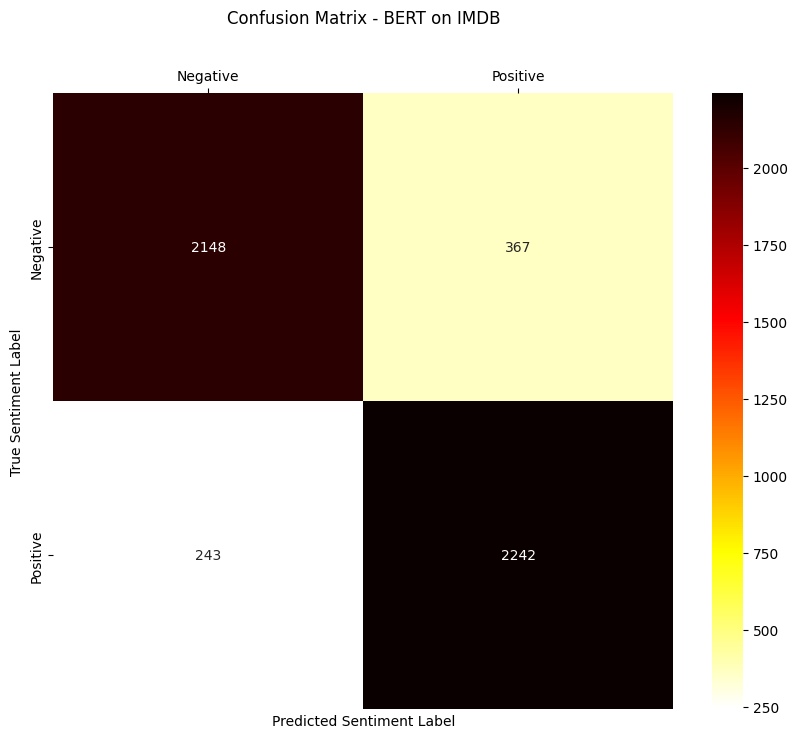

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# --- 1. MODIFICATION TO THE EVALUATION FUNCTION ---
# We need it to return full lists to use in the plot
def evaluate_model_for_plotting(model, data_loader):
    model.eval()
    all_preds = []
    all_true = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs, dim=1)

            # Accumulating results in the list
            all_preds.extend(preds.cpu().numpy())
            all_true.extend(labels.cpu().numpy())

    return all_true, all_preds

# --- 2. PLOT GENERATION (CONFUSION MATRIX) ---

# First, we get the actual validation data
print("Generating data for the confusion matrix...")
final_truelabel_list, final_prediction_list = evaluate_model_for_plotting(model, val_loader)

# --- Code adapted from Medium article ---

# Define class names (In IMDB: 0=Negative, 1=Positive)
class_names = ["Negative", "Positive"]

# Create the confusion matrix
cm = confusion_matrix(final_truelabel_list, final_prediction_list)

# Convert to DataFrame for plotting (using real names instead of 0 and 1)
cm_df = pd.DataFrame(cm,
                     index=class_names,
                     columns=class_names)

# Plot
plt.figure(figsize=(10, 8))
# cmap='Blues' is usually more readable than 'hot_r' for matrices, but logic was kept
g = sns.heatmap(cm_df, cmap='hot_r', annot=True, fmt='g')

g.xaxis.set_ticks_position("top")
g.tick_params(axis='x', rotation=0) # Rotation 0 looks better with just 2 classes
g.set_title("Confusion Matrix - BERT on IMDB", y=1.1)
g.set_xlabel("Predicted Sentiment Label") # Note: X-axis is usually Prediction
g.set_ylabel("True Sentiment Label")      # Y-axis is True Label

plt.show()